## TEST Baseline 1

모든 실험·개선·검증은 이 파일에서 진행한다.

| Step | 내용 |
|---|---|
| 1 | 파일 경로 확인 |
| 2 | 데이터 로드 |
| 3 | 데이터 분석 방향 설정 |
| 4 | 데이터 전처리 및 시각화 |
| 5 | 평가지표 계산 및 손실함수 통한 모형 적합 |
| 6 | 그룹별(KPX_1 / 2/ 3) 개별 모형 학습 |
| 7 |  |
| 8 | 스키마 검증 |
| 9 | 제출 CSV 저장 |

In [ ]:
import os
import sys

import csv
from typing import List
from dataclasses import dataclass, field
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import statsmodels.api as stats

import torch
import torch.nn as nn

In [ ]:
pd.set_option("display.max_columns", None)
# 데이터프레임 생략되는 열 없이 모든 열 조회
pd.options.display.float_format = "{:,.8f}".format
# pd.options.display.float_format = None # 원상복구
# 파이썬 지수 e표현 실수로 변환


## Step 1. 파일 경로 확인
모든 경로 내 파일이 실제로 존재하는지 확인한다.

In [ ]:
@dataclass # __init__ 자동 생성, __post_init__ 자동 호출하는 데코레이터
class WindforceDataLoader:
    """WINDFORCE 데이터 로드를 담당하는 클래스"""
    root: str = "/Users/ksydata/WINDFORCE"
    # 프로젝트 루트 경로 (기본값)
    root_train: str = field(init = False)
    # 학습 데이터 루트 경로, __post_init__에서 채워짐 (생성자 인자로 안 받음)
    root_test: str = field(init = False)                     
    # 평가 데이터 루트 경로, __post_init__에서 채워짐 (생성자 인자로 안 받음)
    encoding: str = "utf-8-sig"
    # "UTF-8 with BOM"("utf-8-sig")으로 csv 파일을 읽고 쓰기 위해 인코딩 설정

    _paths: dict = field(default_factory = dict, init = False)
    # 파일명 -> 경로 매핑 딕셔너리, 초기값은 빈 딕셔너리
    _cache: dict = field(default_factory = dict, init = False)
    # 파일명 -> 로딩된 DataFrame 캐시, 초기값은 빈 딕셔너리

    def __post_init__(self):
        """dataclass의 __init__ 실행 직후 자동 호출되는 메서드"""
        self.root_train = f"{self.root}/TRAIN"
        self.root_test = f"{self.root}/TEST"

        self._paths = {
        # 각 데이터 파일의 논리적 이름과 실제 경로를 매핑
            "ldaps_train": f"{self.root_train}/ldaps_train.csv", # [v]
            # LDAPS 기반 기상 예보 데이터로 각각 학습 기간과 평가 기간의 기상 예보 정보 포함
            # 2022-01-01 01:00:00 ~ 2025-01-01 00:00:00 (약 1.5 km 공간해상도의 16개 격자에 대해 제공)

            "gfs_train": f"{self.root_train}/gfs_train.csv", # [v]
            # GFS 기반 기상 예보 데이터로 각각 학습 기간과 평가 기간의 기상 예보 정보 포함
            # 2022-01-01 01:00:00 ~ 2025-01-01 00:00:00 (약 0.25도 공간해상도의 9개 격자에 대해 제공)

            "ldaps_test": f"{self.root_test}/ldaps_test.csv",
            # LDAPS 기반 기상 예보 데이터 (약 1.5 km 공간해상도의 16개 격자에 대해 제공)
            # 2025-01-01 01:00:00 ~ 2026-01-01 00:00:00

            "gfs_test": f"{self.root_test}/gfs_test.csv",
            # GFS 기반 기상 예보 데이터 (약 0.25도 공간해상도의 9개 격자에 대해 제공)
            # 2025-01-01 01:00:00 ~ 2026-01-01 00:00:00

            "train_labels": f"{self.root_train}/train_labels.csv", # [v]
            # 학습 기간의 KPX 그룹별 실제 발전량 데이터로 해당 값을 정답값으로 활용하여 모델 학습
            # 2022-01-01 01:00:00 ~ 2025-01-01 00:00:00

            "scada_vestas_train": f"{self.root_train}/scada_vestas_train.csv", # [v]
            # VESTAS 제작사의 터빈의 학습 기간 SCADA 실측 데이터
            # 터빈 단위의 운전 및 발전 관련 실측 정보 포함

            "scada_unison_train": f"{self.root_train}/scada_unison_train.csv", # [v]
            # UNISON 제작사의 터빈의 학습 기간 SCADA 실측 데이터
            # 터빈 단위의 운전 및 발전 관련 실측 정보 포함

            "sample_submission": f"{self.root}/INFO/sample_submission.csv",
            # 참고용 sample 제출 양식 (총 8,760개 행으로 구성)
            # 특정 풍력단지(3개 그룹)의 향후 발전량을 예측하는 AI 모델을 통한
            # 평가 기간의 KPX 3그룹별 예측 발전량을 지정된 형식에 맞게 입력하여 제출

            "kpx_info": f"{self.root_train}/kpx_info.csv", # [v]

            # "submission_schema": f"{self.root}/submission.csv",
            # 제출용 sample 양식
        }

    def check_paths(self) -> dict[str, bool]:
        """모든 경로 존재 여부 확인 및 출력하는 메서드"""
        status = {}
        # 결과를 담을 빈 딕셔너리 초기화
        for name, path in self._paths.items():
            # _paths의 모든 (파일명, 경로) 쌍을 순회
            exists = os.path.exists(path) 
            # 해당 경로에 실제 파일이 존재하는지 확인
            status[name] = exists
            # 결과 딕셔너리에 존재 여부 저장
            print(f"{'✅' if exists else '❌'}  {name}: {path}")
        return status
        # 전체 파일의 존재 여부 딕셔너리 반환

    def load(self, name: str, force: bool = False, **kwargs) -> pd.DataFrame: 
        """개별 파일 로드 메서드 (캐싱 지원)"""
        if name not in self._paths:
        # 요청한 파일명이 _paths에 등록되지 않은 경우
            raise KeyError(f"'{name}'은 등록된 파일이 아닙니다. 사용 가능: {list(self._paths.keys())}")
            # 유효한 이름 목록과 함께 에러 발생
        if name in self._cache and not force:  
        # 이미 캐시에 있고 강제 재로딩이 아니면
            return self._cache[name]
            # 캐시된 DataFrame을 바로 반환 (재로딩 방지)

        df = pd.read_csv(self._paths[name], encoding = self.encoding, **kwargs)
        # 지정된 인코딩으로 CSV 파일 읽기
        self._cache[name] = df
        # 읽은 DataFrame을 캐시에 저장
        return df
        # 로딩한 DataFrame 반환

    def load_all(self, force: bool = False) -> dict[str, pd.DataFrame]:
        """전체 파일 로드 메서드"""
        for name in self._paths:
            try: 
            # 개별 파일 로딩 실패가 전체를 중단시키지 않도록 예외 처리
                self.load(name, force = force)
                # 해당 파일 로딩 (내부적으로 캐시에 저장됨)
                print(f"✅ {name}: shape={self._cache[name].shape}")
                # 성공 시 shape(행, 열) 정보 출력
            except Exception as e:
            # 로딩 중 에러 발생 시(파일 없음, 인코딩 오류 등)
                print(f"❌ {name}: {e}")
                # 어떤 파일에서 어떤 에러가 났는지 출력
        return self._cache
        # 지금까지 로딩된 모든 DataFrame 캐시 반환

    def summarize(self, name: str) -> None: 
        """컬럼 및 날짜 범위 요약하는 메서드"""
        df = self.load(name)
        # 해당 파일 로드(단, 캐시에 있으면 캐시 사용)
        print(f"\n[{name}] columns: {list(df.columns)}")
        # 파일명과 전체 컬럼 목록 출력

        date_cols = [c for c in df.columns if any(k in c.lower() for k in ["date", "time", "일시", "시간"])]  
        # 컬럼명에 날짜 관련 키워드가 포함된 컬럼만 추출
        for date_col in date_cols:
            # 추출된 날짜 관련 컬럼들을 순회
            try:
            # 날짜 파싱 실패(형식 오류 등)에 대비한 예외 처리
                parsed = pd.to_datetime(df[date_col])
                # 문자열 컬럼을 datetime 타입으로 변환
                print(f"  {date_col}: {parsed.min()} ~ {parsed.max()}")
                # 해당 컬럼의 최소~최대 날짜 범위 출력
            except Exception:
                # 변환 실패 시
                print(f"  {date_col}: 파싱 실패 (샘플: {df[date_col].iloc[0]})")
                # 실패했다는 메시지와 첫 번째 값 샘플 출력

    def __getitem__(self, name: str) -> pd.DataFrame:
        # loader["파일명"] 형태의 딕셔너리 접근 문법 지원
        return self.load(name)
        # load() 메서드를 그대로 호출하여 반환 (캐싱 로직 재사용)

## Step 2. 데이터 로드 및 구조 확인
- 풍력발전량 예측에서 입력으로 봐야 할 기상 변수는 무엇인가?
- 시간 단위 예측값 제출에서 실수하기 쉬운 포맷은 무엇인가?
- NMAE와 정산금획득률 중 어느 지표가 내 실험 로그에 먼저 들어가야 하는가?

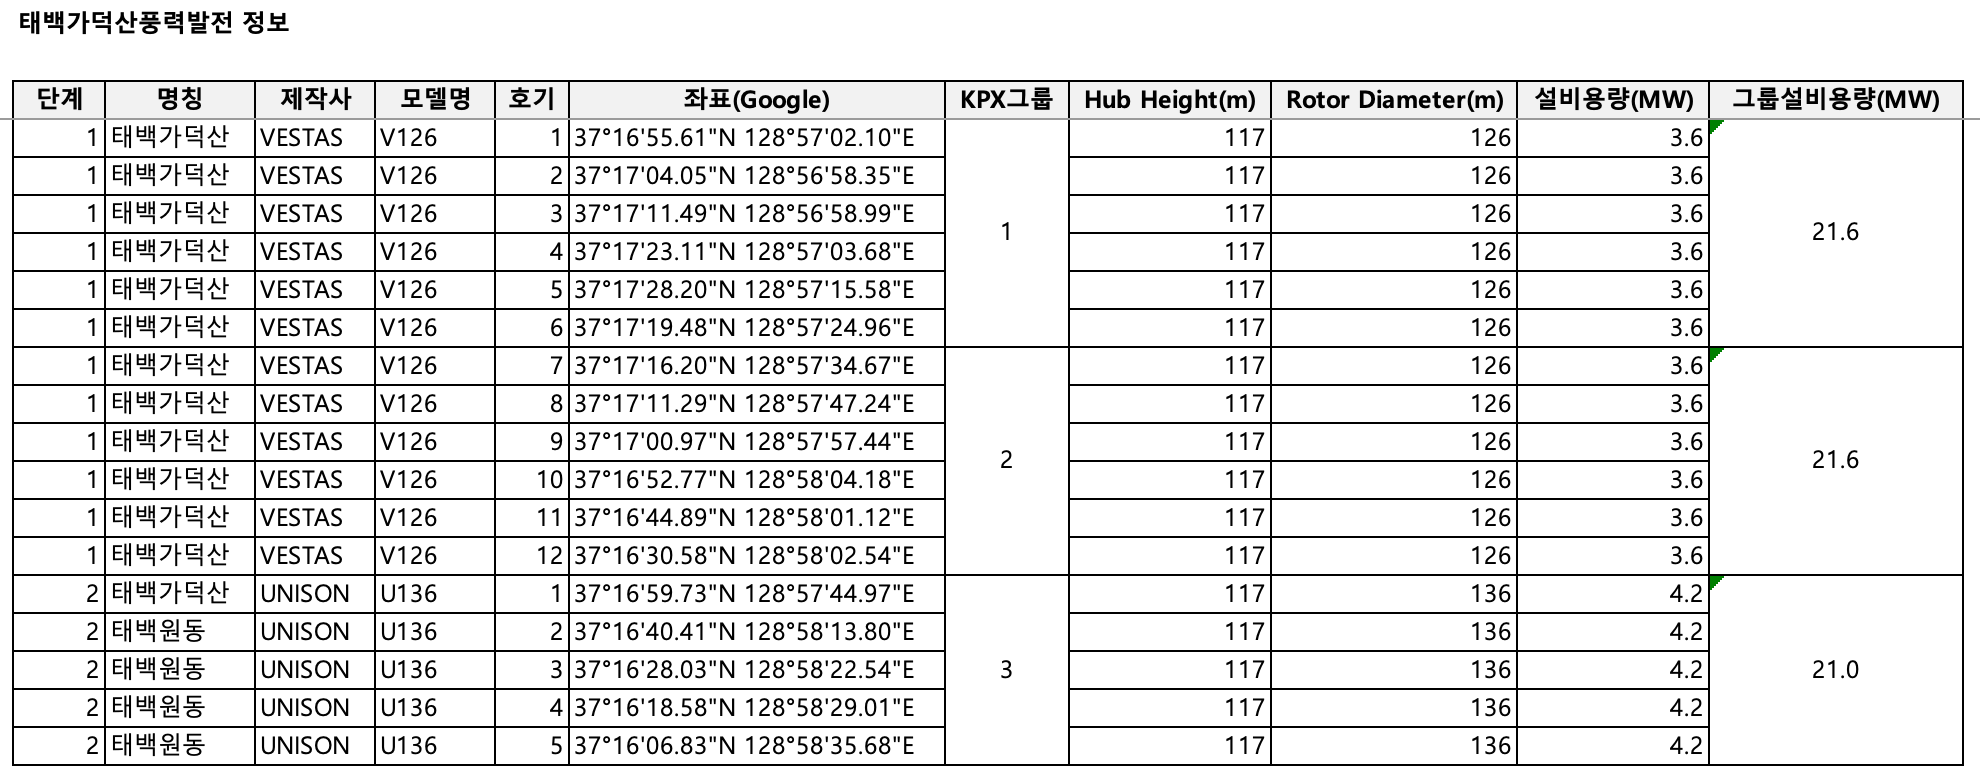

In [ ]:
loader = WindforceDataLoader()   
# 클래스 인스턴스 생성 (root 기본값 사용)
loader.check_paths()             
# 파일 존재 여부 먼저 확인

In [ ]:
loader.load_all()                
# 전체 로딩 및 shape 출력

In [ ]:
print(loader["scada_vestas_train"].info(), loader["scada_unison_train"].info())
# 풍속(Wind Speed) : 가장 중요한 독립변수, 예측 모델의 핵심 입력
# 풍향(Wind Direction) : 요 편차 계산, 효율 손실 분석

In [ ]:
print(loader["train_labels"].head(5))   
print(loader["sample_submission"].head(5))

## Step 3. 데이터 분석 방향 설정

1. 기초 이론 및 방법론 (Domain Foundation)
    - https://news.skecoplant.com/board/17696
  
2. 딥러닝 기반 모델링 (Deep Learning Architectures) 및 시계열 예측
    - http://journal.auric.kr/kiee/XmlViewer/f397619
    - https://kr.mathworks.com/company/user_stories/korea-institute-of-energy-research-develops-ai-based-predictive-maintenance-models-for-offshore-wind-power.html
  
    - 이흥석 외 5인, <LSTM 기법을 이용한 풍력발전 출력 예측에 관한 연구 >, 대한전기학회 논문집 제69권 제8호, 2020.08.p.1,157-1,164 
        - ANN/SVR/LSTM 비교, RMSE·MAPE 평가
    - 최정곤 외 1인, <딥러닝을 이용한 풍력 발전량 예측>, 한국전자통신학회 논문지 제16권 제2호, 2021.02.p.329-338.
        - Bidirectional LSTM + CNN 하이브리드, 풍속/풍향/공기밀도 입력
    - 김동우 외 4인, <풍력발전량 예측을 위한 SCADA DATA 전처리 방안>, 2024년도 대한전기학회 하계학술대회 논문집 2024.07.p.10-13.
  
3. 데이터 엔지니어링 및 특화 기법 (Advanced Feature Engineering)

4. 풍력 발전의 본질 : 에너지 형태의 연쇄 변환
   - $P = \frac{1}{2} \cdot \rho \cdot A \cdot V^3 \cdot C_p$
     - **P** : 풍력 터빈이 바람에서 추출할 수 있는 이론적 출력 (W)
     - **ρ** (rho) : 공기 밀도 (kg/m³). 표준 대기 조건에서 약 1.225 kg/m³. 기온이 올라가거나 고도가 높아지면 공기 밀도가 낮아져 같은 풍속에서도 출력이 줄어듭니다.
     - **A** : 회전면적(swept area: 로터가 회전하면서 만드는 원의 면적). 반지름 r인 로터의 회전면적은 πr²이므로, U136 모델(로터 직경 136m)의 회전면적은 π × 68² ≈ 14,527 m²가 됩니다.
     - **V** : 풍속 (m/s). 세제곱으로 들어가기 때문에 출력에 가장 큰 영향을 미칩니다. 단위 시간에 회전면적 A를 통과하는 공기의 질량(m)이 (ρ×A×V)인 물체의 운동에너지 ½mv²
     - **Cp** : 터빈의 효율(power coefficient), 실제 터빈이 바람의 운동에너지를 추출 가능한 전기에너지 출력
   - 바람 [운동에너지] $\rightarrow$ 블레이드 [회전에너지] $\rightarrow$ 발전기 [전기에너지] $\rightarrow$ 송전 [전력망공급]

5. 풍향-풍속 벡터 변수 (Wind Vector Components)
   - 개념: 풍향(각도)과 풍속을 결합하여, 터빈 정면으로 불어오는 유효 풍속을 계산할 때 사용
   - 공식: $u = v \times \cos(\theta)$, $v_y = v \times \sin(\theta)$ ($\theta$는 풍향 각도)
   - 머신러닝 모델은 "360도"와 "0도"가 사실상 같은 방향이라는 것을 반영하지 못함

6. 공기 밀도 보정 풍속 (Density-Corrected Wind Speed)

| 컬럼 | 의미 |
|---|---|
| `forecast_kst_dtm` | 예보 대상 시각 |
| `data_available_kst_dtm` | 예보 데이터 사용 가능 시각 |
| `grid_id` | LDAPS 격자 ID |
| `latitude` | 격자 위도 |
| `longitude` | 격자 경도 |
| `heightAboveGround_10_10u` | 지상 10 m U 성분 바람 |
| `heightAboveGround_10_10v` | 지상 10 m V 성분 바람 |
| `heightAboveGround_50_50MUmax` | 지상 50 m U 성분 바람 최댓값 |
| `heightAboveGround_50_50MUmin` | 지상 50 m U 성분 바람 최솟값 |
| `heightAboveGround_50_50MVmax` | 지상 50 m V 성분 바람 최댓값 |
| `heightAboveGround_50_50MVmin` | 지상 50 m V 성분 바람 최솟값 |
| `heightAboveGround_5_XBLWS` | 지상 5 m X 방향 경계층 바람 |
| `heightAboveGround_5_YBLWS` | 지상 5 m Y 방향 경계층 바람 |
| `heightAboveGround_2_t` | 지상 2 m 기온 |
| `heightAboveGround_2_dpt` | 지상 2 m 이슬점온도 |
| `heightAboveGround_2_r` | 지상 2 m 상대습도 |
| `heightAboveGround_2_q` | 지상 2 m 비습 |
| `surface_0_sp` | 지표면 기압 |
| `meanSea_0_prmsl` | 해면기압 |
| `etc_0_blh` | 경계층 높이 |
| `surface_0_NDNSW` | 지표면 순 하향 단파복사 |
| `surface_0_NDNLW` | 지표면 순 하향 장파복사 |
| `heightAboveGround_2_SWDIR` | 지상 2 m 직접 단파복사 |
| `heightAboveGround_2_SWDIF` | 지상 2 m 산란 단파복사 |
| `etc_0_hcc` | 상층운량 |
| `etc_0_mcc` | 중층운량 |
| `etc_0_lcc` | 하층운량 |
| `etc_0_VLCDC` | 매우 낮은 층 운량 |
| `surface_0_avg_lsprate` | 지표면 평균 대규모 강수율 |
| `surface_0_lssrate` | 지표면 대규모 강설률 |
| `surface_0_ncpcp` | 지표면 비대류성 강수량 |
| `surface_0_snol` | 지표면 적설 관련 변수 |
| `surface_0_SNOM` | 지표면 융설량 |
| `surface_0_lsm` | 육지/해양 마스크 |
| `surface_0_h` | 지표면 고도 |


| 컬럼 | 의미 |
|---|---|
| `forecast_kst_dtm` | 예보 대상 시각 |
| `data_available_kst_dtm` | 예보 데이터 사용 가능 시각 |
| `grid_id` | GFS 격자 ID |
| `latitude` | 격자 위도 |
| `longitude` | 격자 경도 |
| `heightAboveGround_10_10u` | 지상 10 m U 성분 바람 |
| `heightAboveGround_10_10v` | 지상 10 m V 성분 바람 |
| `heightAboveGround_80_u` | 지상 80 m U 성분 바람 |
| `heightAboveGround_80_v` | 지상 80 m V 성분 바람 |
| `heightAboveGround_100_100u` | 지상 100 m U 성분 바람 |
| `heightAboveGround_100_100v` | 지상 100 m V 성분 바람 |
| `heightAboveGround_2_2t` | 지상 2 m 기온 |
| `heightAboveGround_2_2d` | 지상 2 m 이슬점온도 |
| `heightAboveGround_2_2r` | 지상 2 m 상대습도 |
| `heightAboveGround_2_2sh` | 지상 2 m 비습 |
| `planetaryBoundaryLayer_0_u` | 행성경계층 U 성분 바람 |
| `planetaryBoundaryLayer_0_v` | 행성경계층 V 성분 바람 |
| `planetaryBoundaryLayer_0_VRATE` | 행성경계층 수직 속도 |
| `surface_0_dswrf` | 지표면 하향 단파복사 플럭스 |
| `surface_0_dlwrf` | 지표면 하향 장파복사 플럭스 |
| `surface_0_prate` | 지표면 강수율 |
| `surface_0_tp` | 지표면 총강수량 |
| `surface_0_sp` | 지표면 기압 |
| `meanSea_0_prmsl` | 해면기압 |
| `surface_0_gust` | 지표면 돌풍 |
| `lowCloudLayer_0_lcc` | 하층운량 |
| `middleCloudLayer_0_mcc` | 중층운량 |
| `highCloudLayer_0_hcc` | 상층운량 |
| `atmosphere_0_tcc` | 전운량 |
| `isobaricInhPa_850_t` | 850 hPa 기온 |
| `isobaricInhPa_850_u` | 850 hPa U 성분 바람 |
| `isobaricInhPa_850_v` | 850 hPa V 성분 바람 |
| `isobaricInhPa_850_r` | 850 hPa 상대습도 |
| `isobaricInhPa_700_t` | 700 hPa 기온 |
| `isobaricInhPa_700_u` | 700 hPa U 성분 바람 |
| `isobaricInhPa_700_v` | 700 hPa V 성분 바람 |
| `isobaricInhPa_500_gh` | 500 hPa 지위고도 |
| `isobaricInhPa_500_t` | 500 hPa 기온 |
| `isobaricInhPa_500_u` | 500 hPa U 성분 바람 |
| `isobaricInhPa_500_v` | 500 hPa V 성분 바람 |

## Step 4. 데이터 전처리 및 시각화
1. SCADA 데이터와 Power Curve 비교
https://ihatenumber.tistory.com/entry/%ED%8C%8C%EC%9D%B4%EC%8D%AC-%EC%9C%A0%EC%86%8D-%ED%92%8D%EC%86%8Dspeed-%EC%9C%A0%ED%96%A5-%ED%92%8D%ED%96%A5degree%EC%9D%98-U-V-%EB%B3%80%ED%99%98

In [ ]:
loader["kpx_info"]

In [ ]:
loader["ldaps_train"].head(1)
# LDAPS 기반 기상 예보 데이터로 각각 학습 기간과 평가 기간의 기상 예보 정보 포함

In [ ]:
loader["gfs_train"].head(1)
# GFS 기반 기상 예보 데이터로 각각 학습 기간과 평가 기간의 기상 예보 정보 포함

---

In [ ]:
class FeatureEngineer:
    """데이터 전처리를 담당하는 클래스"""

    def __init__(self):
        pass
        # self.data = dataLoader
        # 결합도 문제 : WindforceDataLoader 인스턴스를 받아서 내부 속성으로 저장
        # loader[["ldaps_train", "gfs_train", "train_labels", "scada_vestas_train", "scada_unison_train"]]
        # 정규화 이전의 문제
        # 이상치와 결측치 처리 방식 결정
    
    def computeWindSpeed(self, u: pd.Series, v: pd.Series) -> pd.Series:
        """기상예보 데이터의 u(동쪽: +, 서쪽: -), v(북쪽: +, 남쪽: -) 성분으로부터 풍속을 계산하는 메서드"""
        windSpeed = np.sqrt(u**2 + v**2)
        return windSpeed
        # 풍속, 풍향을 반대로 u, v(동서, 남북) 성분으로 변환 가능

    def computeWindDirection(self, u: pd.Series, v: pd.Series) -> pd.Series:
        """기상예보 데이터의 u(동쪽: +, 서쪽: -), v(북쪽: +, 남쪽: -) 성분으로부터 풍향을 계산하는 메서드"""
        windDegree = np.degrees( np.arctan2(-u, -v) ) 
        # 풍향은 북쪽 기준 시계방향으로 측정되므로, arctan2(역탄젠트)를 사용하여 각도를 계산 (-180 ~ 180도 범위)
        # 동풍(u = -1, v = 0)일 때 90도, 남풍(u = 0, v = 1)일 때 180도, 서쪽(u = 1, v = 0)일 때 270도\
        # 출발하는 방향을 나타내는 점에 유의
        
        windDirection = (windDegree + 360) % 360
        # 풍향을 0~360도 범위로 변환 (음수 각도를 쓰지 않고 양수화)
        return windDirection
        # np.cos(np.radians(windDirection)), np.sin(np.radians(windDirection))

    def transformWindDirection(self, df: pd.DataFrame, wind_direction_cols: List[str]) -> pd.DataFrame:
        """풍향(Wind Direction) 전처리 메서드
        
        Logics: 
            0도와 360도의 불연속성 해결 및 주기성 반영(sin, cos 변환 등) 
            요 편차/제어 고려
        """
        df = df.copy()
        for col in wind_direction_cols:
            # 풍향 컬럼마다 순회
            radian = np.radians(df[col])
            # 기상학적 각도 풍향을 삼각함수용 라디안 단위로 변환

            df[f"{col}_cos"] = np.cos(radian)
            df[f"{col}_sin"] = np.sin(radian)
            # 머신러닝의 0도-360도 연속성 인지를 위한 주기성 인코딩 (Sin, Cos)
            # 원본 0~360도 스케일은 수치 왜곡을 일으키므로 아래 2개 변수로 대체

            # df = df.drop(columns = [col]) 
            # 필요시 주석 해제
        
        return df

    def calculatePhsyicalLogic(self, df: pd.DataFrame) -> pd.DataFrame:
        """공기밀도 계산 메서드"""
        return df
    
    def interpolateTimeVariable(self, df: pd.DataFrame, time_col: str) -> pd.DataFrame:
        """시간 관련 변수 순환인코딩/보간 등 전처리 메서드"""
        # 베스타스 - 이상치가 너무 많음
        # 유니슨 - 결측값이 너무 많음
        return df


In [ ]:
class LDAPSFeatureEngineer(FeatureEngineer):
    """LDAPS 기상예보 데이터 전처리를 담당하는 클래스
    
    Attributes:
        - 지상 10m : 순간값
        - 지상 50m : 최댓값, 최솟값
        - 지상 5m 경계층 : 순간값                                                                                                                               
    """
    def __init__(self):
        super().__init__()
        # 부모 클래스 FeatureEngineer의 초기화 메서드 호출

    def transformLDAPS(self, df: pd.DataFrame) -> pd.DataFrame:
        """LDAPS 테이블 명세서 기반 전처리 메서드"""
        df = df.copy()
        
        # 1. 고도 및 성분별 바람 벡터 분해 및 결합 (풍속, 세제곱, 풍향, sin, cos 자동 생성)
        df["ldaps_10m_ws_raw"] = self.computeWindSpeed(df["heightAboveGround_10_10u"], df["heightAboveGround_10_10v"])
        df["ldaps_10m_wd_raw"] = self.computeWindDirection(df["heightAboveGround_10_10u"], df["heightAboveGround_10_10v"])
        
        # 지상 50m 최댓값 바람
        df["ldaps_50m_max_ws_raw"] = self.computeWindSpeed(df["heightAboveGround_50_50MUmax"], df["heightAboveGround_50_50MVmax"])
        df["ldaps_50m_max_wd_raw"] = self.computeWindDirection(df["heightAboveGround_50_50MUmax"], df["heightAboveGround_50_50MVmax"])
        
        # 지상 50m 최솟값 바람
        df["ldaps_50m_min_ws_raw"] = self.computeWindSpeed(df["heightAboveGround_50_50MUmin"], df["heightAboveGround_50_50MVmin"])
        df["ldaps_50m_min_wd_raw"] = self.computeWindDirection(df["heightAboveGround_50_50MUmin"], df["heightAboveGround_50_50MVmin"])
        
        # 지상 5m 경계층 바람 (X, Y 방향 성분 사용)
        df["ldaps_5m_bl_ws_raw"] = self.computeWindSpeed(df["heightAboveGround_5_XBLWS"], df["heightAboveGround_5_YBLWS"])
        df["ldaps_5m_bl_wd_raw"] = self.computeWindDirection(df["heightAboveGround_5_XBLWS"], df["heightAboveGround_5_YBLWS"])
        
        wd_cols = [
            "ldaps_10m_wd_raw", 
            "ldaps_50m_max_wd_raw", 
            "ldaps_50m_min_wd_raw", 
            "ldaps_5m_bl_wd_raw"]
        
        df = self.transformWindDirection(df, wind_direction_cols = wd_cols)
        # 부모 클래스 메서드로 풍향 주기성 인코딩 일괄 적용 (0도-360도 속성 부여 및 Sin/Cos 추출)
        
        return df

In [ ]:
class GFSFeatureEngineer(FeatureEngineer):
    """GFS 기상예보 데이터 전처리를 담당하는 클래스
    
    Attributes:
        - 지상 10m : 순간값
        - 지상 80m : 순간값
        - 지상 100m : 순간값
        - 행성경계층(PBL) 바람      
        - 850 hPa 상층 바람    
        - 700 hPa 상층 바람
        - 500 hPa 상층 바람                                                                                               
    """
    def __init__(self):
        super().__init__()
        # 부모 클래스 FeatureEngineer의 초기화 메서드 호출

    def transformGFS(self, df: pd.DataFrame) -> pd.DataFrame:
        """GFS 테이블 명세서 기반 전처리 메서드"""
        df = df.copy()
        
        # 고도 및 성분별 바람 벡터 분해 및 결합
        gfs_mapping = {
            # GFS 데이터 내 각 고도/기압 레벨별 U, V 성분 컬럼 명세 매핑 정의
            "gfs_10m": ("heightAboveGround_10_10u", "heightAboveGround_10_10v"),
            "gfs_80m": ("heightAboveGround_80_u", "heightAboveGround_80_v"),
            "gfs_100m": ("heightAboveGround_100_100u", "heightAboveGround_100_100v"),
            "gfs_pbl": ("planetaryBoundaryLayer_0_u", "planetaryBoundaryLayer_0_v"),
            "gfs_850hPa": ("isobaricInhPa_850_u", "isobaricInhPa_850_v"),
            "gfs_700hPa": ("isobaricInhPa_700_u", "isobaricInhPa_700_v"),
            "gfs_500hPa": ("isobaricInhPa_500_u", "isobaricInhPa_500_v")
        }
        # Key: 새롭게 생성될 변수들의 접두사(Prefix)
        # Value: (동서방향 U 성분 컬럼명, 남북방향 V 성분 컬럼명)
        
        ws_cols = []
        wd_cols = []
        # 부모 클래스의 일괄 처리 메서드로 넘겨주기 위해 고도별 새 변수명을 담을 리스트        
        
        for prefix, (u_col, v_col) in gfs_mapping.items():
            # for 루프를 돌며 각 고도별 U, V 벡터 성분을 물리적 풍속(m/s)과 기상학적 풍향(0~360도)으로 복원            
            if u_col in df.columns and v_col in df.columns:
                ws_name = f"{prefix}_ws_raw" # 생성될 물리 절대 풍속 컬럼명
                wd_name = f"{prefix}_wd_raw" # 생성될 기상학적 각도 풍향 컬럼명
                
                df[ws_name] = self.computeWindSpeed(df[u_col], df[v_col])
                # u, v 화살표의 총 길이(절대 풍속)를 계산
                df[wd_name] = self.computeWindDirection(df[u_col], df[v_col])
                # 북쪽 0도 기준, 시계방향으로 불어오는 풍향 각도(0~360) 계산
                
                ws_cols.append(ws_name)
                wd_cols.append(wd_name)
                # 일괄 파생 변수 생성을 위한 리스트 업로드
        
        df = self.transformWindDirection(df, wind_direction_cols = wd_cols)
        # 부모 클래스 메서드로 풍향 주기성 인코딩 일괄 적용 (Sin/Cos 변환)

        return df

In [ ]:
ldaps_engineer = LDAPSFeatureEngineer()
gfs_engineer = GFSFeatureEngineer()

In [ ]:
ldaps_transformed_df = ldaps_engineer.transformLDAPS(loader["ldaps_train"])
gfs_transformed_df = gfs_engineer.transformGFS(loader["gfs_train"])

In [ ]:
ldaps_transformed_df.head(2)

In [ ]:
gfs_transformed_df.head(2)

In [ ]:
def check_pearson_assumptions(x, y):
    """피어슨 상관계수 가정 검토"""

    # 1. 선형성 검토
    from scipy import stats
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

    # 2. 정규성 검토
    from scipy.stats import shapiro
    shapiro_x = shapiro(x)
    shapiro_y = shapiro(y)

    # 3. 이상치 검토
    def detect_outliers(data):
        q1 = np.percentile(data, 25)
        q3 = np.percentile(data, 75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        outliers = [i for i, val in enumerate(data) if val < lower_bound or val > upper_bound]
        return outliers

    outliers_x = detect_outliers(x)
    outliers_y = detect_outliers(y)

    print("=== 피어슨 상관계수 가정 검토 ===")
    print(f"1. 선형성 (R²): {r_value**2:.3f}")
    print(f"2. X 정규성 (Shapiro p-value): {shapiro_x[1]:.3f}")
    print(f"3. Y 정규성 (Shapiro p-value): {shapiro_y[1]:.3f}")
    print(f"4. X 이상치 개수: {len(outliers_x)}")
    print(f"5. Y 이상치 개수: {len(outliers_y)}")

    # 권장사항
    recommendations = []
    if r_value**2 < 0.5:
        recommendations.append("선형성이 약함 - 스피어만 상관계수 고려")
    if shapiro_x[1] < 0.05 or shapiro_y[1] < 0.05:
        recommendations.append("정규성 가정 위반 - 스피어만 상관계수 고려")
    if len(outliers_x) > 0 or len(outliers_y) > 0:
        recommendations.append("이상치 존재 - 로버스트 방법 고려")

    if recommendations:
        print("\n권장사항:")
        for rec in recommendations:
            print(f"- {rec}")
    else:
        print("\n모든 가정이 충족되어 피어슨 상관계수 사용 가능")

# 예제
x = np.random.normal(0, 1, 100)
y = 2 * x + np.random.normal(0, 0.5, 100)
check_pearson_assumptions(x, y)


In [ ]:
def correlation_pairplot(data, vars=None):
    """산점도 매트릭스 그리기"""

    if vars is None:
        vars = data.columns[:6]  # 처음 6개 변수만

    # 산점도 매트릭스
    sns.pairplot(data[vars], diag_kind='kde')
    plt.show()

    # 상관관계 매트릭스
    corr_matrix = data[vars].corr()

    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_matrix, 
                annot=True, 
                cmap='coolwarm', 
                center=0,
                square=True,
                fmt='.2f')
    plt.title('상관관계 매트릭스')
    plt.tight_layout()
    plt.show()

# 예제
correlation_pairplot(df)


---

In [ ]:
loader["scada_vestas_train"].head(1)

In [ ]:
# 풍력단지별 터빈 단위 SCADA 풍력, 풍속, 발전량 데이터(VESTAS 제작사, 12개 호기)
for columnName in ["vestas_wtg01", "vestas_wtg02", "vestas_wtg03", 
                   "vestas_wtg04", "vestas_wtg05", "vestas_wtg06", 
                   "vestas_wtg07", "vestas_wtg08", "vestas_wtg09", 
                   "vestas_wtg10", "vestas_wtg11", "vestas_wtg12"]:
    print(columnName, "\n", loader["scada_vestas_train"].filter(like = columnName).describe())
    # .groupby.agg(["min", "max", "mean", "std"])
    # 이상치로 추정되는 발전량 유의(마이너스 값 또는 설비용량 600kw을 초과하는 값)

In [ ]:
loader["scada_unison_train"].head(1)

In [ ]:
# 풍력단지별 터빈 단위 SCADA 풍력, 풍속, 발전량 데이터(UNISON 제작사, 5개 호기)
for columnName in ["unison_wtg01", "unison_wtg02", "unison_wtg03", 
                   "unison_wtg04", "unison_wtg05"]:
    print(columnName, "\n", loader["scada_unison_train"].filter(like = columnName).describe())

In [ ]:
# 풍력단지별 터빈 단위 SCADA 풍력, 풍속, 발전량 데이터 산점도
# 풍향, 풍속, 발전량의 입체적 관계 확인

target_df = loader["scada_unison_train"]
# 분석할 대상 데이터셋 선택

target_cols = []
# 대상 컬럼 자동 추출 (unison_wtg로 시작하는 컬럼들만 추출)
for col in target_df.columns:
    # target_cols를 뽑을 때 suffix(_ws, _wd 등)를 제거한 '순수 터빈명'만 추출
    if col.startswith("unison_wtg"):
        # _ws, _wd, _power_kw10m 중 하나로 끝나는 컬럼에서 접두어만 추출
        base_name = col.replace("_ws", "").replace("_wd", "").replace("_power_kw10m", "")
        if base_name not in target_cols:
            target_cols.append(base_name)
# target_cols = [col for col in target_df.columns if col.startswith("unison_wtg")]

print(f"Found {len(target_cols)} turbines for visualization.")
# 컬럼 개수 출력

# 루프를 돌며 시각화 수행
for col in target_cols:
    # 데이터에 실제 컬럼이 존재하는지 확인 (suffix 조합 확인)
    ws_col = f"{col}_ws"
    wd_col = f"{col}_wd"
    pw_col = f"{col}_power_kw10m"
    
    if (ws_col in target_df.columns) and (wd_col in target_df.columns) and (pw_col in target_df.columns):
        fig = px.scatter_3d(  
            # 3D 데이터이므로 scatter_3d를 사용
            target_df, 
            x = ws_col, y = wd_col, z = pw_col,
            color = pw_col,
            # 발전량에 따라 점 색상 변경
            color_continuous_scale = "Viridis",
            title = f"[{col}] Wind Speed vs Direction vs Power", 
            labels = {
                ws_col: "Wind Speed (m/s)", 
                wd_col: "Wind Direction (°)", 
                pw_col: "Power (kW)"
            },
            opacity = 0.7  
            # 점들이 겹칠 수 있으므로 투명도 조절
        )
        
        fig.update_layout(margin = dict(l = 0, r = 0, b = 0, t = 40))
        # 차트 레이아웃 개선        
        fig.show()
        break  # 테스트용으로 첫 번째 터빈만 시각화하고 루프 종료

    else:
        print(f"Skipping {col}: Required columns ({ws_col}, {wd_col}, {pw_col}) not found.")

In [ ]:
# 풍력단지별 터빈 단위 SCADA 풍속, 발전량 데이터 산점도 (2D 버전)

for col in target_cols:
    ws_col = f"{col}_ws"
    pw_col = f"{col}_power_kw10m"
    
    if (ws_col in target_df.columns) and (pw_col in target_df.columns):
        fig = px.scatter(
            target_df,
            x = ws_col, 
            y = pw_col, 
            # X: 풍속, Y: 발전량
            title = f"[{col}] Wind Speed vs Power", 
            labels = {
                ws_col: "Wind Speed (m/s)", 
                pw_col: "Power (kW)"
            },
            opacity = 0.4,
            color = pw_col, 
            # 발전량에 따라 점 색상 변경
            color_continuous_scale = "Cividis" 
            # 색상 테마
        )
        
        fig.update_layout(margin = dict(l = 0, r = 0, b = 0, t = 30))
        fig.show()
        break  # 테스트용으로 첫 번째 터빈만 시각화하고 루프 종료

    else:
        print(f"Skipping {col}: Required columns not found.")


In [ ]:
# 풍력단지별 터빈 단위 SCADA 풍력, 풍속, 발전량 데이터 산점도 (2D 버전)

for col in target_cols:
    wd_col = f"{col}_wd"
    pw_col = f"{col}_power_kw10m"
    
    if (wd_col in target_df.columns) and (pw_col in target_df.columns):
        fig = px.scatter(
            target_df,
            x = wd_col, 
            y = pw_col, 
            # X: 풍향, Y: 발전량
            title = f"[{col}] Wind Direction vs Power", 
            labels = {
                wd_col: "Wind Direction (°)", 
                pw_col: "Power (kW)"
            },
            opacity = 0.4,
            color = pw_col, 
            # 발전량에 따라 점 색상 변경
            color_continuous_scale = "Plasma"
            # 색상 테마
        )
        
        fig.update_layout(margin=dict(l=0, r=0, b=0, t = 30))
        fig.show()
        break  # 테스트용으로 첫 번째 터빈만 시각화하고 루프 종료
    
    else:
        print(f"Skipping {col}: Required columns not found.")


In [ ]:
# 루프를 돌며 파워 커브 그리기
# 제조사 파워 커브 비교 시각화 코드 어떻게 할지

for col in target_cols:
    ws_col = f"{col}_ws"
    pw_col = f"{col}_power_kw10m"
    
    if (ws_col in target_df.columns) and (pw_col in target_df.columns):
        
        # 데이터 정제: 풍속 0 이상, 발전량 0 이상인 유효 데이터만 사용
        # 풍속이 너무 낮거나(0근처) 발전량이 이상한 데이터는 곡선을 망칩니다.
        curve_df = target_df[[ws_col, pw_col]].dropna()
        curve_df = curve_df[(curve_df[ws_col] > 0.5) & (curve_df[pw_col] >= 0)]
        
        # 데이터가 너무 많으면 렌더링이 느리므로 샘플링 (시각화용)
        if len(curve_df) > 3000:
            curve_df = curve_df.sample(3000)

        # 파워 커브 그리기 (Scatter + Trendline)
        # trendline="lowess"를 사용하면 복잡한 수식 없이도 S자 곡선 형태를 아주 잘 잡아냅니다.
        fig = px.scatter(
            curve_df, 
            x = ws_col, 
            y = pw_col,
            # mode = "markers",
            # name = "Measured (SCADA Data)",
            trendline = "lowess", 
            trendline_color_override = "red", 
            # 곡선 색상을 빨간색으로 지정
            title = f"[{col}] Power Curve (Wind Speed vs Power)",
            labels = {ws_col: "Wind Speed (m/s)", pw_col: "Power (kW)"},
            opacity = 0.4,
            template = "plotly_white" 
            # 배경을 하얗게 하여 곡선이 잘 보이게 함
        )
        
        # 그래프 레이아웃 정리
        fig.update_layout(margin=dict(l=0, r=0, b=0, t=40))
        fig.show()
        break  # 테스트용으로 첫 번째 터빈만 시각화하고 루프 종료

    else:
        print(f"Skipping {col}: Required columns not found.")

## Step 5. 평가지표 계산 및 손실함수 통한 모형 적합

1. 평가지표 (대회 규정)
   - 1-NMAE : 그룹별 NMAE_g = mean(|pred-actual|/설비용량) 을 3개 그룹 평균낸 뒤 1에서 뺀 값. 높을수록 좋음.
   - FICR   : 시간별 NMAE 구간에 따라 FICR의 단가(6% 이하: 4원, 6~8%: 3원, 8% 초과: 0원)가 달라짐.
           FICR_g = 획득 정산금 / 이론상 최대 정산금(=항상 NMAE<=6% 가정 시 4원 단가 적용).
           3개 그룹 FICR 평균.
   - 총점   : 0.5*(1-NMAE) + 0.5*FICR
2. 손실함수
   - loss = 1 - 총점 = 0.5*NMAE + 0.5*(1-FICR)
      - NMAE 항: |예측값-실제값| 그대로 사용 (미분 가능)
      - FICR 항: 정산 단가 계단함수(4/3/0원)를 시그모이드로 완화해 미분 가능하게 근사
        k가 클수록 실제 계단함수에 가까워짐 (기본값 300).
      - actual_power_kw: 발전량 가중치(FICR은 발전량 가중 평균이므로 필요).

In [ ]:
'''
class EvaluationMetrics:
    """평가지표(1-NMAE, 정산금획득률(FICR) 계산하는 클래스"""

    def __init__(self):
        pass

    def evaluateNAME(self):
        """1-NMAE(KPX 3그룹 평균 예측 정확도) 계산 메서드
        
        Logic:
            NMAE(Normalized Mean Absolute Error)
            = Σ{((KPX_i의 시간당 예측 발전량 - 실제 발전량) / (KPX_i의 시간당 설비용량(kWh))}/시간
            = (NMAE_1 + NMAE_2 + NMAE_3) / 3
            (i = 1,2,3)
        """

        pass

    def evaluateFICR(self):
        """정산금획득률(FICR) 계산 메서드
        
        Logic:
            시간별 발전량 예측값과 실제값을 비교하여 단가 계산하여 정산금 계산 
            실제 획득 정산금(단가x실제 발전량)과 이론상 최대 정산금(4원x실제 발전량, 모든 시간대 오차율 6%) 
            비교하여 획득률 계산
        """

        # 단가 계산 근사식
        # NMAE <= 0.06 : 3*1 + 1*1 = 4(원)
        # 0.06 < NMAE <= 0.08 : 3*1 + 1*0 = 3(원)
        # 0.08 < NMAE : 3*0 + 1*0 = 0(원)

        pass
    
    pass
'''

## Step 6. 그룹별(KPX_1 / 2/ 3) 개별 모형 학습